<a href="https://colab.research.google.com/github/paulocarvalhoprcf/dataset-tcc/blob/main/TCC_2025_Univesp_Previs%C3%A3o_para_o_S%26P500_e_o_Ibovespa_curvas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
dados = pd.read_csv('dataset.csv')
dados['Data'] = pd.to_datetime(dados['Data'])
dados.set_index('Data', inplace=True)
dados.head()

,BRL/USD,S&P500,XAU/USD,Crude,CPI,IBOV,IPCA
Data,,,,,,,
1994-07-01,0.9625,446.2,386.95,17.57,148.4,3581,148.4
1994-07-04,0.9350,446.2,386.95,17.47,148.4,3623,148.4
1994-07-05,0.9250,446.4,386.05,17.38,148.4,3581,148.4
1994-07-06,0.9100,446.1,383.95,17.06,148.4,3564,148.4
1994-07-07,0.9080,448.4,384.65,17.08,148.4,3754,148.4


In [ ]:
# Selecionando as colunas necessárias
features = ['BRL/USD', 'XAU/USD', 'Crude', 'CPI', 'IBOV']  # Variáveis independentes
target = 'S&P500'  # Variável dependente (S&P500)

# Normalizando os dados (MinMaxScaler transforma os dados para o intervalo [0, 1])
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(dados[features + [target]])

# Convertendo os dados em formato de séries temporais para LSTM
def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(seq_length, len(data)):
        sequences.append(data[i-seq_length:i, :-1])  # Features
        labels.append(data[i, -1])  # Target (S&P500)
    return np.array(sequences), np.array(labels)

SEQ_LENGTH = 252  # Usar os últimos 252 dias úteis (1 ano) para prever o próximo dia
X, y = create_sequences(scaled_data, SEQ_LENGTH)

# Dividindo em conjuntos de treino e teste (80% treino, 20% teste)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Construindo o modelo LSTM
model = Sequential()
model.add(LSTM(units=64, return_sequences=True, input_shape=(SEQ_LENGTH, len(features))))
model.add(Dropout(0.1))
model.add(LSTM(units=32))
model.add(Dropout(0.1))
model.add(Dense(units=1))  # Saída única para prever o valor de S&P500

model.compile(optimizer='adam', loss='mean_squared_error')

# Treinando o modelo
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop])

# Prevendo nos dados de teste
y_pred = model.predict(X_test)

# Revertendo a normalização para visualizar os valores reais
y_test_rescaled = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_test.reshape(-1, 1)), axis=1))[:, -1]
y_pred_rescaled = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_pred), axis=1))[:, -1]

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 59s 276ms/step - loss: 0.0034 - val_loss: 0.0250
Epoch 2/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 83s 282ms/step - loss: 0.0013 - val_loss: 0.0212
Epoch 3/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 55s 287ms/step - loss: 9.8963e-04 - val_loss: 0.0064
Epoch 4/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 80s 279ms/step - loss: 6.5064e-04 - val_loss: 0.0066
Epoch 5/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 83s 282ms/step - loss: 6.1163e-04 - val_loss: 0.0158
Epoch 6/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 82s 284ms/step - loss: 5.2622e-04 - val_loss: 0.0295
Epoch 7/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 55s 285ms/step - loss: 4.4212e-04 - val_loss: 0.0255
Epoch 8/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 54s 280ms/step - loss: 3.4359e-04 - val_loss: 0.0240
Epoch 9/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 83s 289ms/step - loss: 2.9575e-04 - val_loss: 0.0367
Epoch 10/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 82s 290ms/step - loss: 2.6201e-04 - val_loss: 0.0339
Epoch 11/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 55s 287ms/step - loss: 2.

In [ ]:
# Calculando o RMSE
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
print(f'RMSE: {rmse}')

RMSE: 451.37835417902


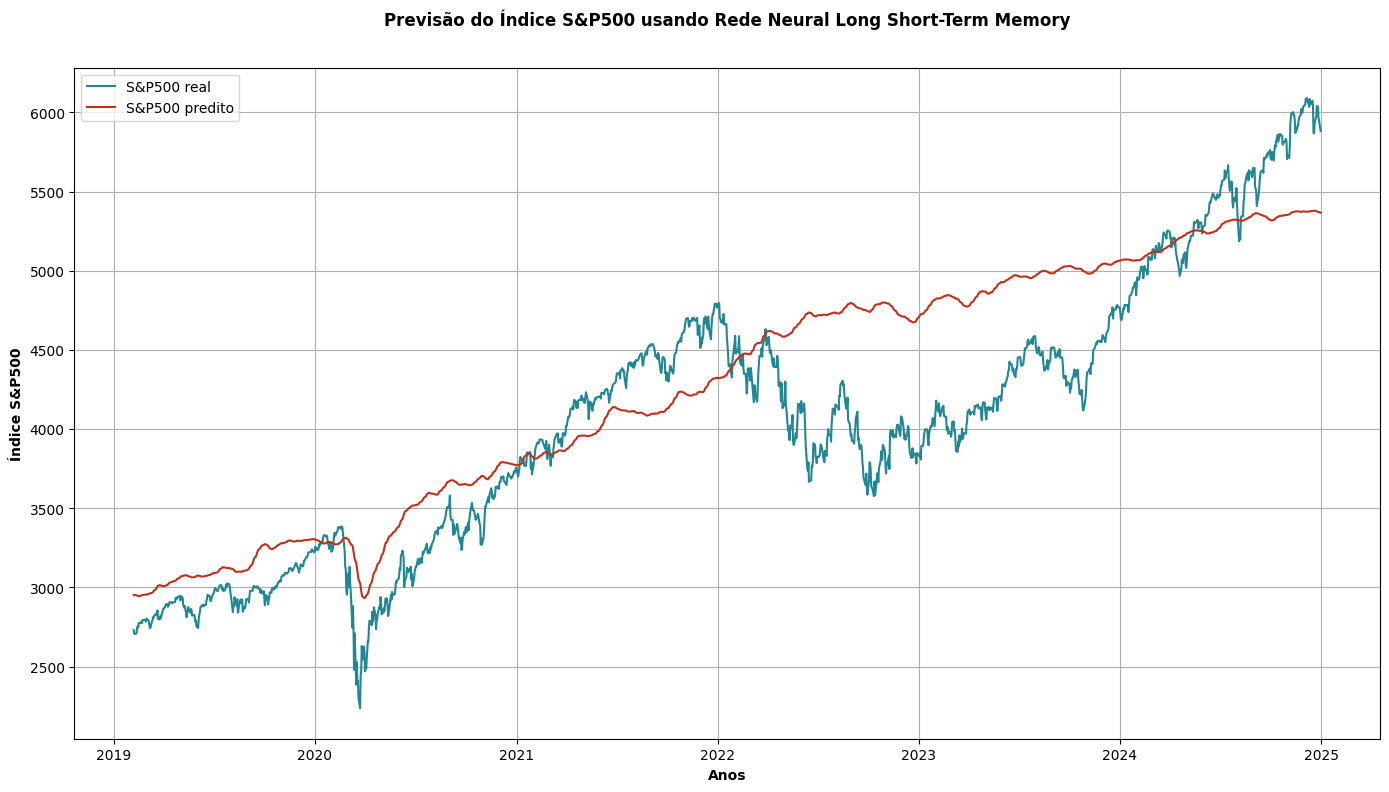

In [ ]:
# Plotando os resultados
plt.figure(figsize=(14, 8))

# Obter o índice da para o período de teste
test_index = dados.index[SEQ_LENGTH + train_size:]

# Plotando os valores reais e os previstos para o conjunto de teste
plt.plot(test_index, y_test_rescaled, label='S&P500 real', color='#228794')
plt.plot(test_index, y_pred_rescaled, label='S&P500 predito', color='#bf311b')

plt.title('Previsão do Índice S&P500 usando Rede Neural Long Short-Term Memory', fontdict={'fontsize': 12}, weight='bold', y=1.05)
plt.xlabel('Anos', fontdict={'fontsize': 10}, weight='bold')
plt.ylabel('Índice S&P500', fontdict={'fontsize': 10}, weight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('prediction_s&p500_lstm.png')
plt.show()

In [ ]:
# Selecionando as colunas necessárias
features = ['BRL/USD', 'XAU/USD', 'CPI', 'S&P500']  # Variáveis independentes
target = 'IBOV'  # Variável dependente (IBOV)

# Normalizando os dados (MinMaxScaler transforma os dados para o intervalo [0, 1])
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(dados[features + [target]])

# Convertendo os dados em formato de séries temporais para LSTM
def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(seq_length, len(data)):
        sequences.append(data[i-seq_length:i, :-1])  # Features
        labels.append(data[i, -1])  # Target (S&P500)
    return np.array(sequences), np.array(labels)

SEQ_LENGTH = 252  # Usar os últimos 252 dias úteis (1 ano) para prever o próximo dia
X, y = create_sequences(scaled_data, SEQ_LENGTH)

# Dividindo em conjuntos de treino e teste (80% treino, 20% teste)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Construindo o modelo LSTM
model = Sequential()
model.add(LSTM(units=64, return_sequences=True, input_shape=(SEQ_LENGTH, len(features))))
model.add(Dropout(0.1))
model.add(LSTM(units=32))
model.add(Dropout(0.1))
model.add(Dense(units=1))  # Saída única para prever o valor de IBOV

model.compile(optimizer='adam', loss='mean_squared_error')

# Treinando o modelo
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop])

# Prevendo nos dados de teste
y_pred = model.predict(X_test)

# Revertendo a normalização para visualizar os valores reais
y_test_rescaled = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_test.reshape(-1, 1)), axis=1))[:, -1]
y_pred_rescaled = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_pred), axis=1))[:, -1]

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


193/193 ━━━━━━━━━━━━━━━━━━━━ 55s 268ms/step - loss: 0.0157 - val_loss: 0.0687
Epoch 2/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 76s 239ms/step - loss: 0.0034 - val_loss: 0.0511
Epoch 3/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 84s 251ms/step - loss: 0.0032 - val_loss: 0.0377
Epoch 4/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 82s 253ms/step - loss: 0.0023 - val_loss: 0.0150
Epoch 5/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 81s 251ms/step - loss: 0.0017 - val_loss: 0.0155
Epoch 6/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 83s 258ms/step - loss: 0.0013 - val_loss: 0.0202
Epoch 7/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 47s 246ms/step - loss: 0.0012 - val_loss: 0.0195
Epoch 8/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 82s 246ms/step - loss: 0.0012 - val_loss: 0.0234
Epoch 9/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 83s 250ms/step - loss: 0.0011 - val_loss: 0.0363
Epoch 10/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 45s 234ms/step - loss: 0.0011 - val_loss: 0.0137
Epoch 11/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 81s 232ms/step - loss: 0.0011 - val_loss: 0.0188
Epoch 12/100
193/193

In [ ]:
# Calculando o RMSE
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
print(f'RMSE: {rmse}')

RMSE: 10539.276115021617


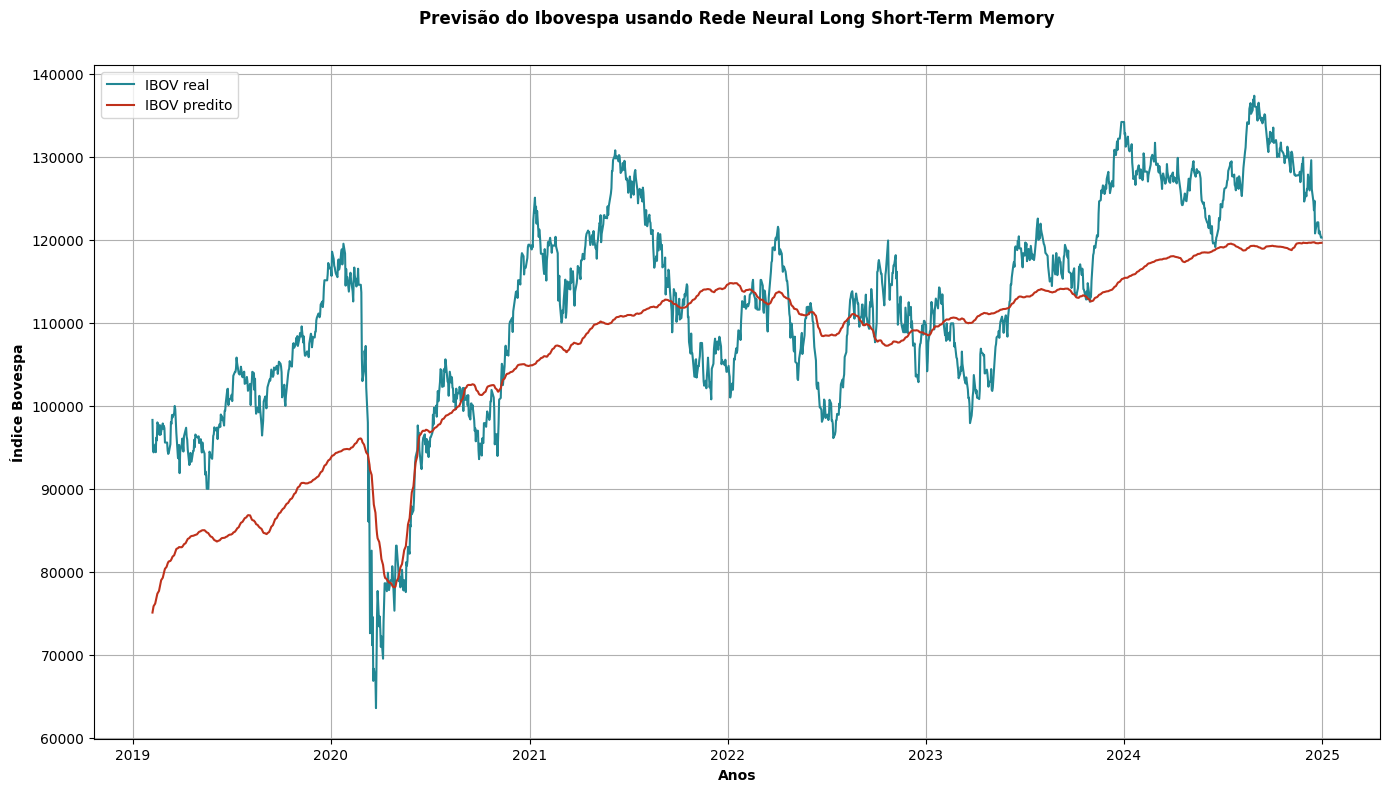

In [ ]:
# Plotando os resultados
plt.figure(figsize=(14, 8))

# Obter o índice da para o período de teste
test_index = dados.index[SEQ_LENGTH + train_size:]

# Plotando os valores reais e os previstos para o conjunto de teste
plt.plot(test_index, y_test_rescaled, label='IBOV real', color='#228794')
plt.plot(test_index, y_pred_rescaled, label='IBOV predito', color='#bf311b')

plt.title('Previsão do Ibovespa usando Rede Neural Long Short-Term Memory', fontdict={'fontsize': 12}, weight='bold', y=1.05)
plt.xlabel('Anos', fontdict={'fontsize': 10}, weight='bold')
plt.ylabel('Índice Bovespa', fontdict={'fontsize': 10}, weight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('prediction_ibov_lstm.png')
plt.show()